In [1]:
import pandas as pd
#get cg74 related cgs in a list
file_path = "../inflammation_HANNUM_with_proper_selection/cd_74_associated_cpgs.txt"
with open(file_path, "r") as file:
    cd_74_associated_cpgs_list = [line.strip() for line in file]  # Removes any trailing newlines
cd_74_associated_cpgs_set=set(cd_74_associated_cpgs_list)
#read how the cgs were when trained
with open("inflamm_hugging_elnet_all_cg_order.txt", "r") as f:
    elnet_all_cg_order = [line.strip() for line in f.readlines()]

#read meta
bench_meta = pd.read_csv('computage_bench_meta.tsv', sep='\t', index_col=0).T
bench_meta.columns = bench_meta.columns.str.lower()
#delete duplicate cols
bench_meta = bench_meta.loc[:, ~bench_meta.columns.duplicated(keep='first')]

In [ ]:
#dont run unnecessary, takes a long time to read
benchmark_betas_UNMODIFIABLE = pd.read_pickle('benchmark_betas.pkl') #takes 15m to read
#drop duplicate cols
benchmark_betas_UNMODIFIABLE = benchmark_betas_UNMODIFIABLE.loc[:, ~benchmark_betas_UNMODIFIABLE.columns.duplicated(keep='first')]
benchmark_betas = benchmark_betas_UNMODIFIABLE.copy()

In [ ]:
#keep only rows which are in the infl_cg_set
benchmark_betas = benchmark_betas[benchmark_betas.index.isin(cd_74_associated_cpgs_set)] #all the cg sites are present
benchmark_betas =benchmark_betas.dropna(axis=1, thresh=len(benchmark_betas) * 0.5)
# Drop columns with more than 250 missing values
benchmark_betas = benchmark_betas.loc[:, benchmark_betas.isnull().sum() <= 250]
#keep the same in meta as in betas
bench_meta = bench_meta[benchmark_betas.columns]
#fill nans with mean
benchmark_betas.fillna(benchmark_betas.mean(), inplace=True)
#now order the betas cgs to the same as in training, so we can easily predict
benchmark_betas = benchmark_betas.loc[elnet_all_cg_order]

In [ ]:
import joblib
#load the model
model_filename='./xgboost_model_5.4MAE.pkl'
loaded_pipeline = joblib.load(model_filename)

In [ ]:
import numpy as np

predictions_list = []

# Loop over each column in the DataFrame and predict age
for col in benchmark_betas.columns:
    X_test = np.array(benchmark_betas[col]).reshape(1, -1)  # Reshape the column into the right shape
    prediction = loaded_pipeline.predict(X_test)[0]  # Get prediction for the current column
    predictions_list.append(prediction)  # Append the prediction to the list

In [ ]:
#create an aggregated DataFrame with the predictions
predictions_np = np.array(predictions_list)
meta_important=bench_meta.loc[['Age','Class','Gender','Tissue']]
meta_important.loc['Predictions']=predictions_np

In [8]:
import numpy as np
import scipy.stats as stats

# Extract X and Y values
x_values = meta_important.loc['Age'].astype(float)  # Convert to float if necessary
y_values = meta_important.loc['Predictions'].astype(float)

# Calculate Mean Absolute Error (MAE)
mae = np.mean(np.abs(y_values - x_values))

# Calculate Pearson correlation coefficient (r)
pearson_r, _ = stats.pearsonr(x_values, y_values)

# Print results
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Pearson Correlation Coefficient (r): {pearson_r:.4f}")

Mean Absolute Error (MAE): 13.8731
Pearson Correlation Coefficient (r): 0.4733


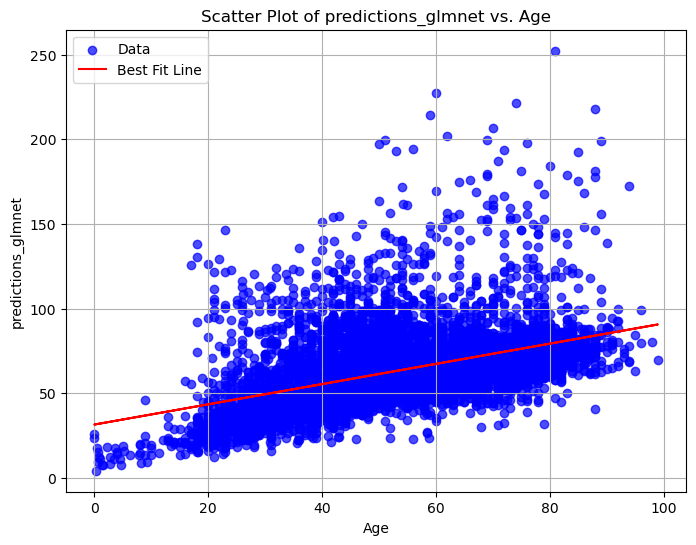

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Extract X and Y values for the scatter plot
x_values = meta_important.loc['Age']
y_values = meta_important.loc['Predictions']

# Calculate the line of best fit using polyfit
slope, intercept = np.polyfit(list(x_values), list(y_values), 1)  # 1 indicates a linear fit

# Store the best fitting line function for later use
def best_fit_line(x):
    return slope * x + intercept

# Generate the y-values for the best fitting line
y_best_fit = best_fit_line(x_values)

# Plot the scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(x_values, y_values, color='blue', alpha=0.7, label='Data')

# Plot the best fit line
plt.plot(x_values, y_best_fit, color='red', label='Best Fit Line')

# Labels and title
plt.xlabel('Age')
plt.ylabel('predictions xgboost')
plt.title('Plot of Predictionsvs. Age')

# Add a legend
plt.legend()

# Show the plot with grid
plt.grid(True)
plt.show()

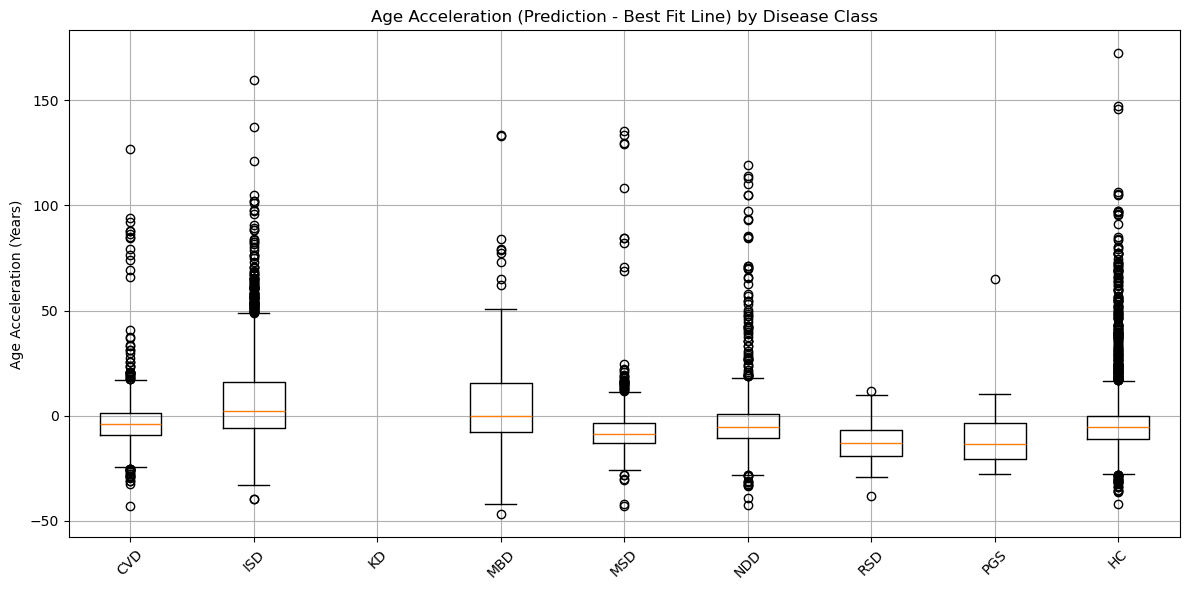

T-Test on Age Acceleration (each class vs HC):
--------------------------------------------------
CVD vs HC:
  T-statistic: -0.8225
  P-value: 0.4109
  ❌ Not statistically significant (p ≥ 0.05)

ISD vs HC:
  T-statistic: 19.5006
  P-value: 0.0000
  ✅ Statistically significant (p < 0.05)

KD vs HC:
  T-statistic: nan
  P-value: nan
  ❌ Not statistically significant (p ≥ 0.05)

MBD vs HC:
  T-statistic: 3.6932
  P-value: 0.0004
  ✅ Statistically significant (p < 0.05)

MSD vs HC:
  T-statistic: -6.1694
  P-value: 0.0000
  ✅ Statistically significant (p < 0.05)

NDD vs HC:
  T-statistic: -1.1344
  P-value: 0.2567
  ❌ Not statistically significant (p ≥ 0.05)

RSD vs HC:
  T-statistic: -7.2404
  P-value: 0.0000
  ✅ Statistically significant (p < 0.05)

PGS vs HC:
  T-statistic: -2.8251
  P-value: 0.0077
  ✅ Statistically significant (p < 0.05)



In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import pandas as pd

# Define relevant disease classes
disease_classes = ['CVD','ISD','KD','MBD','MSD','NDD','RSD','PGS','HC']

# Extract age and predictions
age_values = pd.to_numeric(meta_important.loc['Age'], errors='coerce')
predictions = pd.to_numeric(meta_important.loc['Predictions'], errors='coerce')
class_values = meta_important.loc['Class']

# Calculate the best fit line using polyfit
slope, intercept = np.polyfit(age_values, predictions, 1)

# Define the best fit line function
def best_fit_line(x):
    return slope * x + intercept

# Calculate acceleration as the distance from the best fit line
def calculate_distance(real_age, predicted_age):
    diff = predicted_age - best_fit_line(real_age)  # Vertical distance from the best fit line
    return diff

# Calculate acceleration for each sample
acceleration = [calculate_distance(age, pred) for age, pred in zip(age_values, predictions)]

# Group acceleration values by class
grouped_acceleration = {
    cls: np.array(acceleration)[class_values == cls]  # Group by class, ensure NaN values are handled
    for cls in disease_classes
}

# Boxplot setup
plt.figure(figsize=(12, 6))
positions = np.arange(len(disease_classes)) + 1

for i, cls in enumerate(disease_classes):
    plt.boxplot(grouped_acceleration[cls], positions=[positions[i]], widths=0.5)

plt.xticks(positions, disease_classes, rotation=45)
plt.title('Age Acceleration (Prediction - Best Fit Line) by Disease Class')
plt.ylabel('Age Acceleration (Years)')
plt.grid(True)
plt.tight_layout()
plt.show()

# Optional: T-tests vs HC on acceleration
hc_acceleration = grouped_acceleration['HC']

print("T-Test on Age Acceleration (each class vs HC):")
print("-" * 50)
for cls in disease_classes:
    if cls == 'HC':
        continue
    t_stat, p_value = stats.ttest_ind(grouped_acceleration[cls], hc_acceleration, equal_var=False)

    print(f"{cls} vs HC:")
    print(f"  T-statistic: {t_stat:.4f}")
    print(f"  P-value: {p_value:.4f}")
    if p_value < 0.05:
        print("  ✅ Statistically significant (p < 0.05)")
    else:
        print("  ❌ Not statistically significant (p ≥ 0.05)")
    print()


In [12]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.preprocessing import LabelEncoder

meta_copy = meta_important.copy().T
# 1. One-hot encode categorical variables
df_encoded = pd.get_dummies(meta_copy, columns=['Class', 'Gender', 'Tissue'], drop_first=True)

# 2. Separate dependent and independent variables
y = df_encoded['Predictions'].astype(float)
X = df_encoded.drop(columns=['Predictions'])

# 3. Add intercept
X = sm.add_constant(X)

# 4. Convert everything explicitly to float to avoid object dtype
X = X.astype(float)

# 5. Fit OLS model
model = sm.OLS(y, X).fit()

# 6. Show summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            Predictions   R-squared:                       0.294
Model:                            OLS   Adj. R-squared:                  0.293
Method:                 Least Squares   F-statistic:                     381.6
Date:                Tue, 01 Apr 2025   Prob (F-statistic):               0.00
Time:                        19:47:50   Log-Likelihood:                -42888.
No. Observations:               10100   AIC:                         8.580e+04
Df Residuals:                   10088   BIC:                         8.589e+04
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            18.5778      1.068     17.394

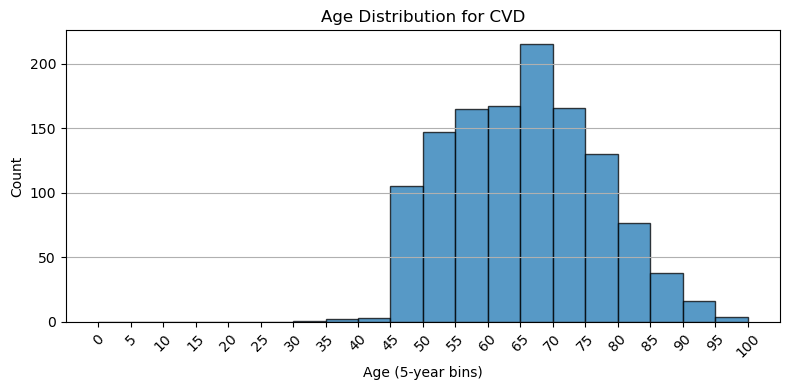

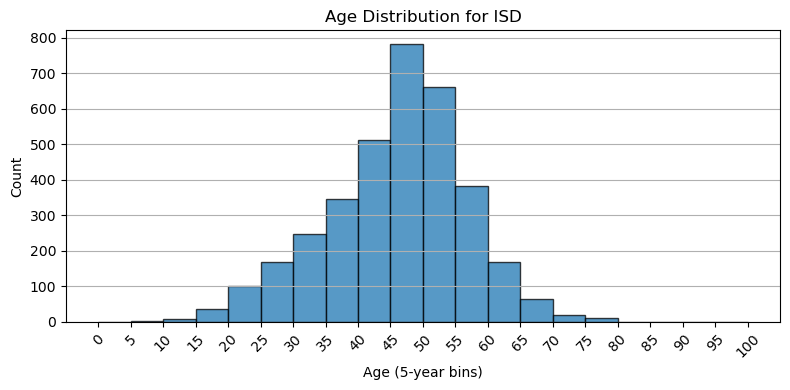

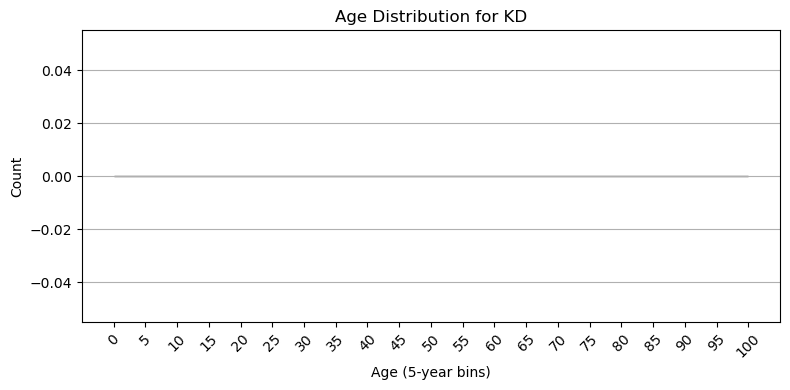

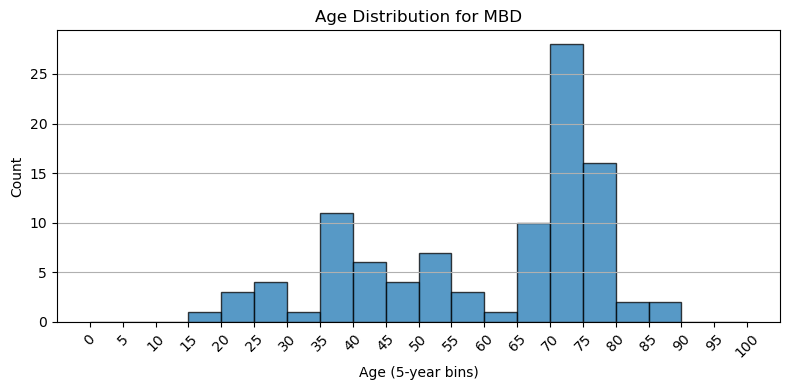

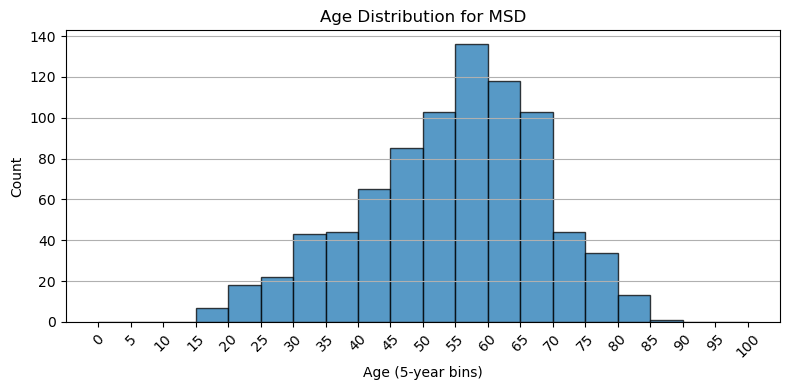

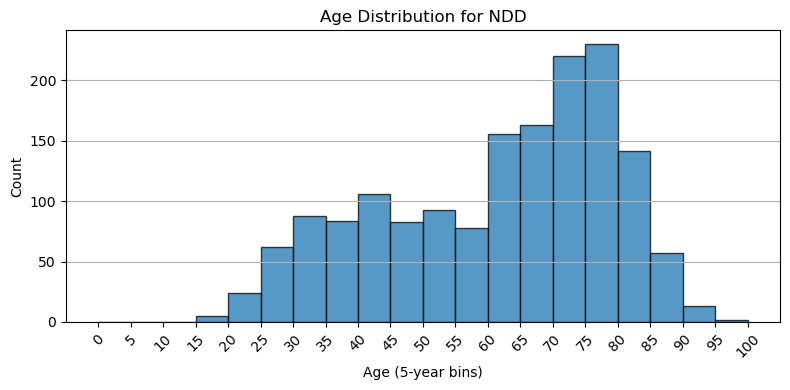

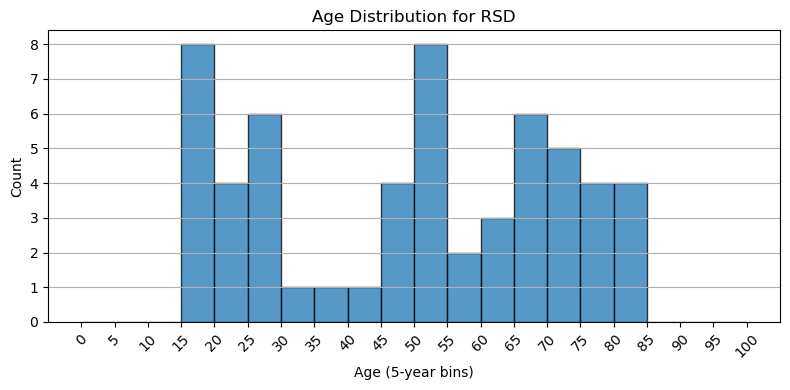

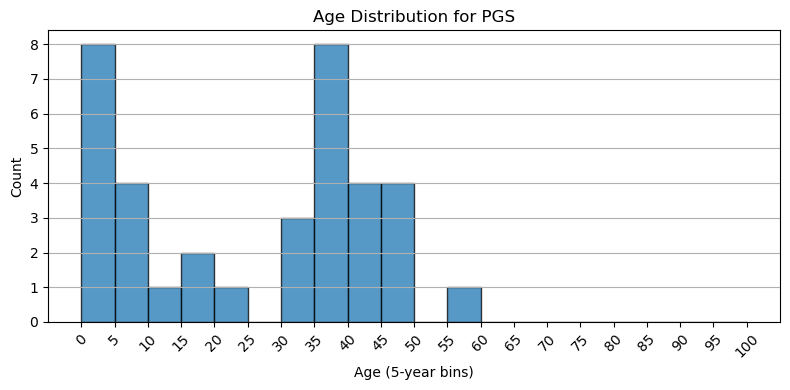

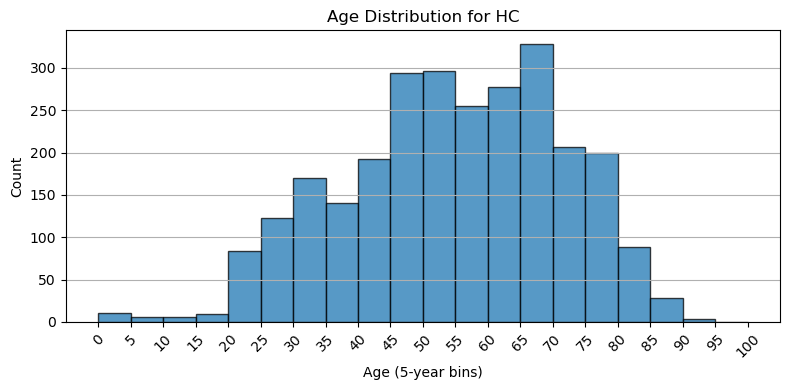

In [15]:
import matplotlib.pyplot as plt
import pandas as pd

# Extract data
x_values = pd.to_numeric(meta_important.loc['Age'], errors='coerce')
class_values = meta_important.loc['Class']

# Filter to only relevant classes
relevant_classes = ['CVD','ISD','KD','MBD','MSD','NDD','RSD','PGS','HC']
class_mask = class_values.isin(relevant_classes)

# Apply class mask to ages and classes
filtered_ages = x_values[class_mask]
filtered_classes = class_values[class_mask]

# Group ages by class
age_groups = {
    cls: filtered_ages[filtered_classes == cls].dropna().astype(float).tolist()
    for cls in relevant_classes
}

# Compute global age bins (5-year intervals)
all_ages = [age for group in age_groups.values() for age in group]
age_min, age_max = int(min(all_ages)), int(max(all_ages))
bins = list(range(age_min - age_min % 5, age_max + 5, 5))

# Plot histograms
for cls, ages in age_groups.items():
    plt.figure(figsize=(8, 4))
    plt.hist(ages, bins=bins, edgecolor='black', alpha=0.75)
    plt.title(f'Age Distribution for {cls}')
    plt.xlabel('Age (5-year bins)')
    plt.ylabel('Count')
    plt.grid(axis='y')
    plt.xticks(bins, rotation=45)
    plt.tight_layout()
    plt.show()
